In [1]:
import pandas as pd 
df =pd.read_csv('heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# EDA

In [3]:
df.info

<bound method DataFrame.info of      Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisea

In [4]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [6]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

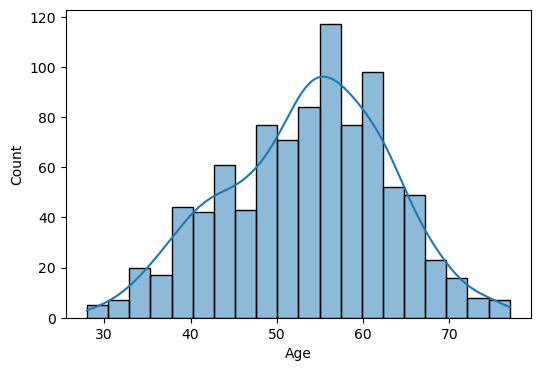

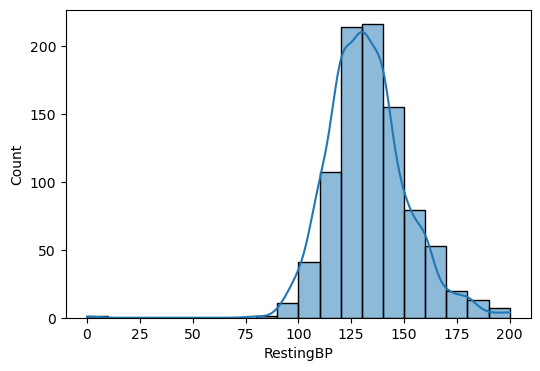

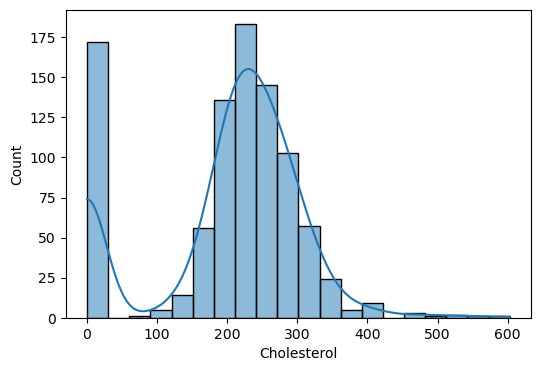

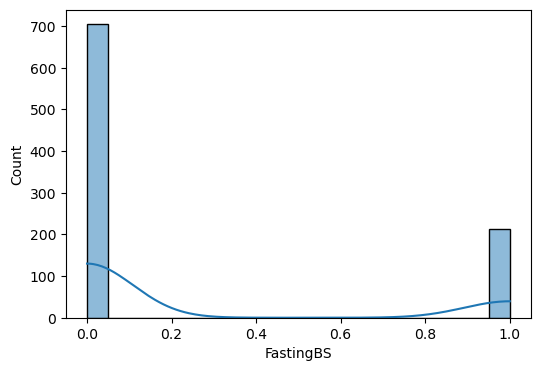

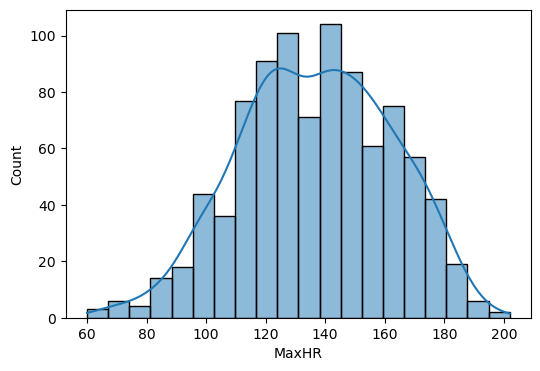

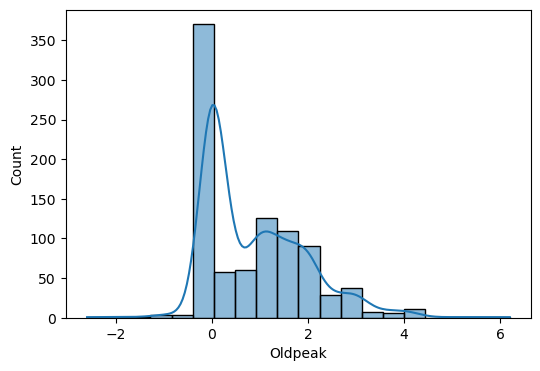

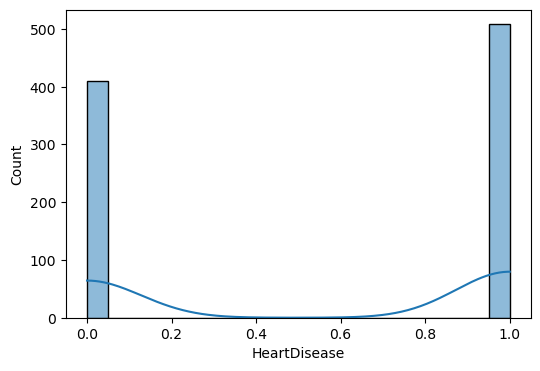

In [7]:
numeric_columns = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde = True,bins = 20)
               

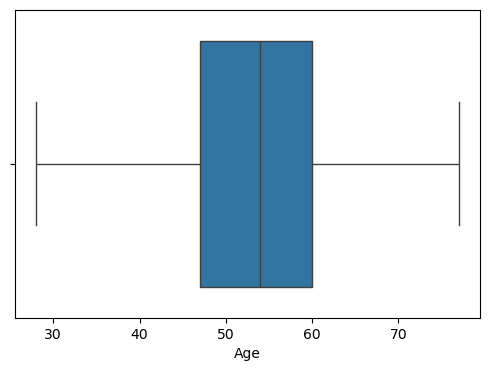

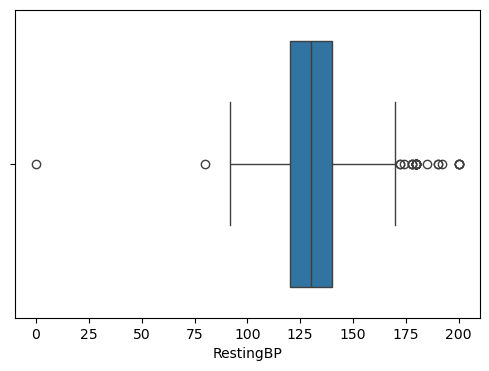

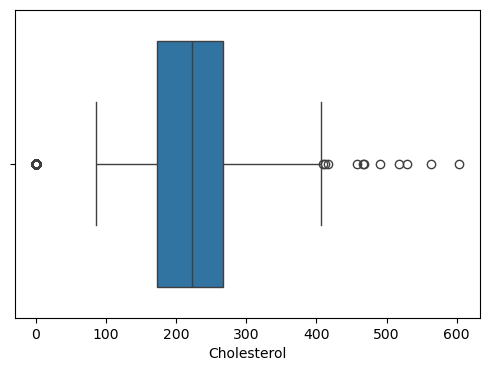

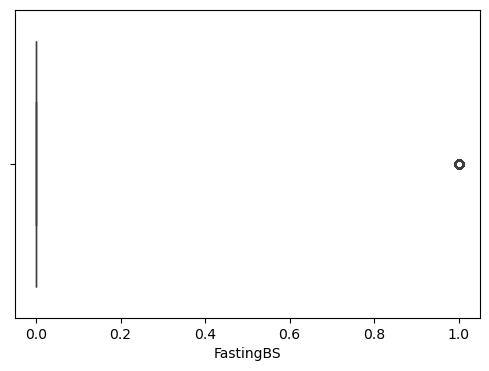

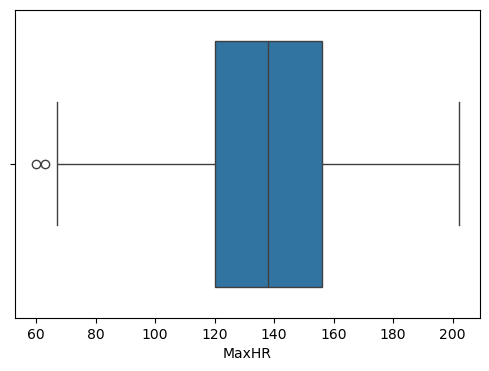

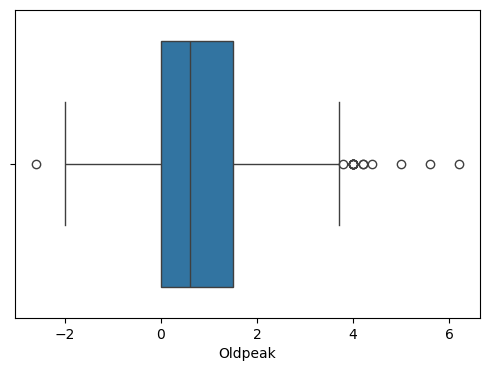

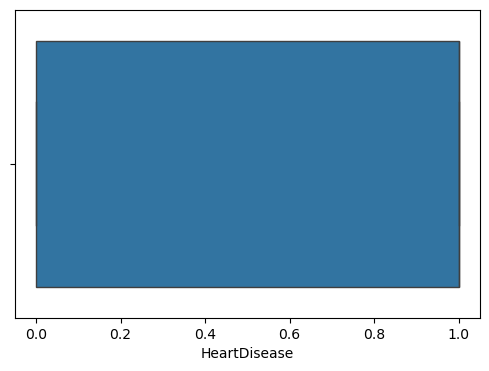

In [8]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[col])

<Axes: >

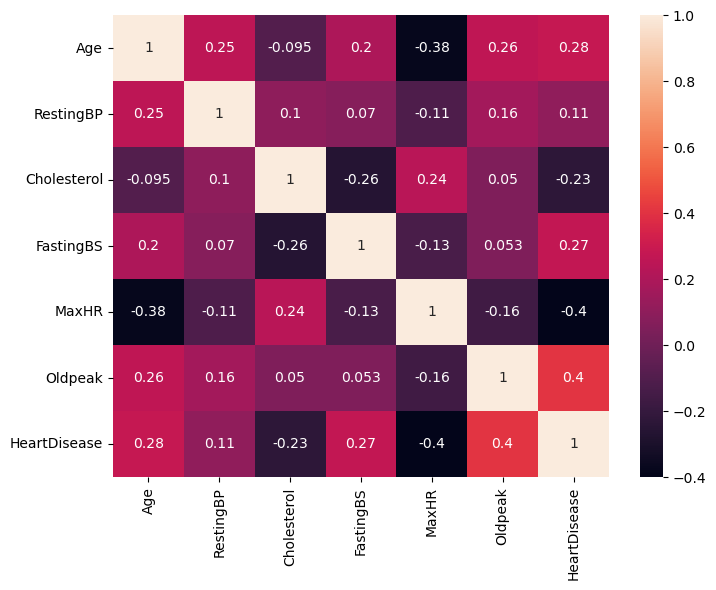

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only = True),annot = True)


In [10]:
df_cleaned = df.copy()
df_cleaned.shape

(918, 12)

In [11]:
df_cleaned.drop_duplicates(inplace = True)
df_cleaned.shape

(918, 12)

In [12]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [13]:
df['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

In [14]:
df['ST_Slope'].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

In [15]:
df['ExerciseAngina'].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

In [16]:
df['RestingECG'].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

In [17]:
df['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [18]:
df_cleaned = df.copy()

In [19]:
df_cleaned

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


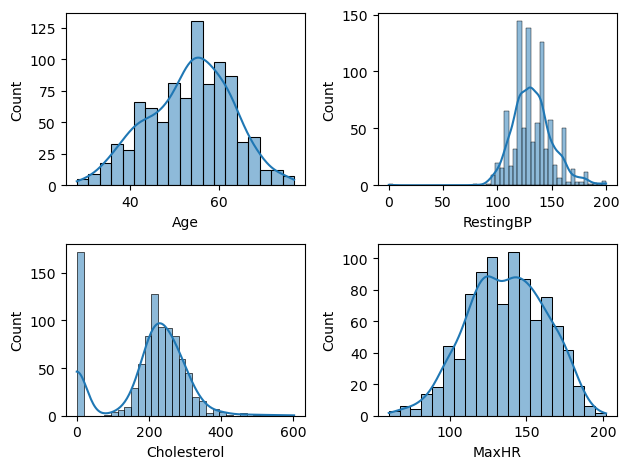

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('heart.csv')
def plotting (var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde = True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

In [21]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [23]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [24]:
ch_mean = df.loc[df['Cholesterol'] != 0,'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [25]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean*0.75)
df['Cholesterol'] = df['Cholesterol'].round(2)

Resting_BP_mean = df.loc[df['RestingBP'] != 0,'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0,Resting_BP_mean)
df['RestingBP'] = df['RestingBP'].round(2)

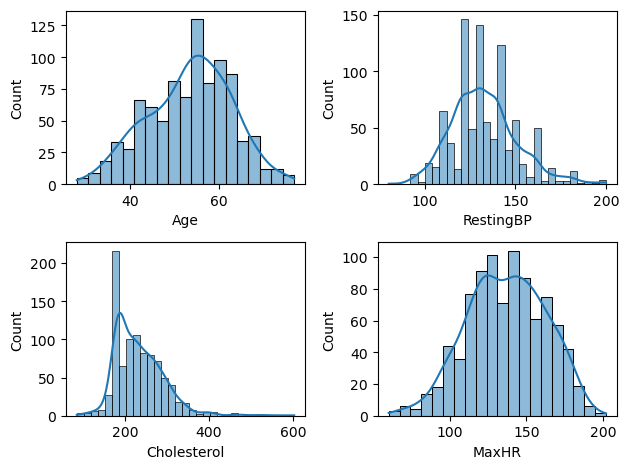

In [26]:
def plotting (var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde = True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

In [27]:
df['Cholesterol'].value_counts()

Cholesterol
183.48    172
254.00     11
223.00     10
220.00     10
230.00      9
         ... 
392.00      1
316.00      1
153.00      1
466.00      1
131.00      1
Name: count, Length: 222, dtype: int64

In [28]:
df['FastingBS'].value_counts()

FastingBS
0    704
1    214
Name: count, dtype: int64

<Axes: xlabel='ChestPainType', ylabel='count'>

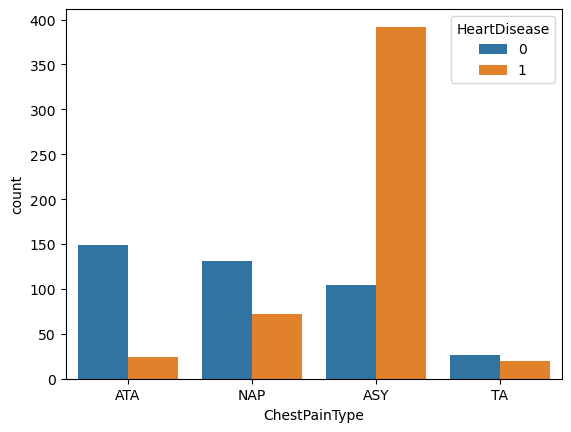

In [29]:
sns.countplot(x = df['ChestPainType'],hue = df['HeartDisease'])

In [30]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

<Axes: xlabel='RestingECG', ylabel='count'>

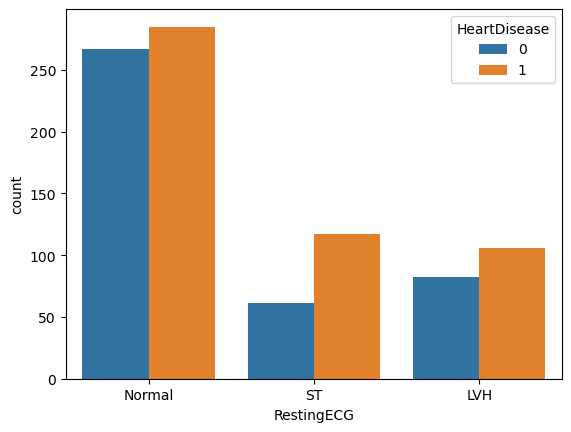

In [31]:
sns.countplot(x = df['RestingECG'],hue = df['HeartDisease'])

<Axes: xlabel='ST_Slope', ylabel='count'>

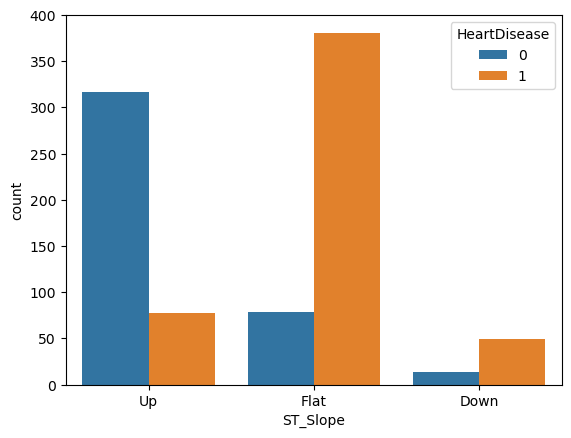

In [32]:
sns.countplot(x = df['ST_Slope'],hue = df['HeartDisease'])

In [33]:
df['Sex'] = df['Sex'].map({"M" : 1,"F" : 0})

In [34]:
df['ExerciseAngina'] = df['ExerciseAngina'].map({"Y" : 1,"N" : 0})
df.rename(columns ={
    'Sex' : 'Is_Male','ExerciseAngina' : 'Have_ExerciseAngina'
},inplace = True)
df.head()

,Age,Is_Male,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,Have_ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140.0,289.0,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160.0,180.0,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130.0,283.0,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138.0,214.0,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150.0,195.0,0,Normal,122,0,0.0,Up,0


In [35]:
df = pd.get_dummies(df,columns = ['ChestPainType','RestingECG','ST_Slope'])
df = df.astype(int)
df.head()

,Age,Is_Male,RestingBP,Cholesterol,FastingBS,MaxHR,Have_ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0,0,0,0,1,0,0,1,0,0,0,1


In [36]:
from sklearn.preprocessing import StandardScaler
numerical_cols =['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df.head()

,Age,Is_Male,RestingBP,Cholesterol,FastingBS,MaxHR,Have_ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,1,0.414885,0.956351,0,1.382928,0,-0.727592,0,0,1,0,0,0,1,0,0,0,1
1,-0.478484,0,1.527224,-0.908019,0,0.754157,0,0.282891,1,0,0,1,0,0,1,0,0,1,0
2,-1.751359,1,-0.141284,0.853725,0,-1.525138,0,-0.727592,0,0,1,0,0,0,0,1,0,0,1
3,-0.584556,0,0.303651,-0.326472,0,-1.132156,1,0.282891,1,1,0,0,0,0,1,0,0,1,0
4,0.051881,1,0.971054,-0.651454,0,-0.581981,0,-0.727592,0,0,0,1,0,0,1,0,0,0,1


In [37]:
# pearson correlation
from scipy.stats import pearsonr
selected_features = ['Age','Is_Male','RestingBP','Cholesterol','FastingBS','MaxHR','Have_ExerciseAngina',
                     'Oldpeak','ChestPainType_ASY','ChestPainType_ATA','ChestPainType_NAP',
                     'ChestPainType_TA','RestingECG_LVH','RestingECG_Normal','RestingECG_ST',
                     'ST_Slope_Down','ST_Slope_Flat','ST_Slope_Up']

correlations = {
    feature: pearsonr(df[feature],df['HeartDisease'])[0]
for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
16,ST_Slope_Flat,0.554134
8,ChestPainType_ASY,0.516716
6,Have_ExerciseAngina,0.494282
7,Oldpeak,0.392385
1,Is_Male,0.305445
0,Age,0.282039
4,FastingBS,0.267291
15,ST_Slope_Down,0.122527
2,RestingBP,0.117909
14,RestingECG_ST,0.102527


In [38]:
# Get a list of all current column names
cols = list(df.columns)

# Remove 'HeartDisease' from its current position
cols.remove('HeartDisease')

# Add 'HeartDisease' to the end of the list
cols.append('HeartDisease')

# Reorder the DataFrame using the new list
df = df[cols]
df.head()

,Age,Is_Male,RestingBP,Cholesterol,FastingBS,MaxHR,Have_ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,HeartDisease
0,-1.433140,1,0.414885,0.956351,0,1.382928,0,-0.727592,0,1,0,0,0,1,0,0,0,1,0
1,-0.478484,0,1.527224,-0.908019,0,0.754157,0,0.282891,0,0,1,0,0,1,0,0,1,0,1
2,-1.751359,1,-0.141284,0.853725,0,-1.525138,0,-0.727592,0,1,0,0,0,0,1,0,0,1,0
3,-0.584556,0,0.303651,-0.326472,0,-1.132156,1,0.282891,1,0,0,0,0,1,0,0,1,0,1
4,0.051881,1,0.971054,-0.651454,0,-0.581981,0,-0.727592,0,0,1,0,0,1,0,0,0,1,0


In [39]:
print(df.columns.tolist())

['Age', 'Is_Male', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Have_ExerciseAngina', 'Oldpeak', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up', 'HeartDisease']


In [45]:
df_final = df[['Age', 'Is_Male', 'RestingBP', 'FastingBS', 'MaxHR', 'Have_ExerciseAngina', 'Oldpeak',
'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP'
    , 'ST_Slope_Down','ST_Slope_Flat', 'ST_Slope_Up',]]
df_final.head()

,Age,Is_Male,RestingBP,FastingBS,MaxHR,Have_ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,HeartDisease
0,-1.433140,1,0.414885,0,1.382928,0,-0.727592,0,1,0,0,0,1,0
1,-0.478484,0,1.527224,0,0.754157,0,0.282891,0,0,1,0,1,0,1
2,-1.751359,1,-0.141284,0,-1.525138,0,-0.727592,0,1,0,0,0,1,0
3,-0.584556,0,0.303651,0,-1.132156,1,0.282891,1,0,0,0,1,0,1
4,0.051881,1,0.971054,0,-0.581981,0,-0.727592,0,0,1,0,0,1,0


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

X = df_final.drop('HeartDisease',axis = 1)
y= df_final['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM (RBF Kernel)": SVC(probability=True)
}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4)
    })
results   

[{'Model': 'Logistic Regression', 'Accuracy': 0.8587, 'F1 Score': 0.8738},
 {'Model': 'KNN', 'Accuracy': 0.8315, 'F1 Score': 0.8473},
 {'Model': 'Naive Bayes', 'Accuracy': 0.8424, 'F1 Score': 0.8571},
 {'Model': 'Decision Tree', 'Accuracy': 0.7989, 'F1 Score': 0.8103},
 {'Model': 'SVM (RBF Kernel)', 'Accuracy': 0.8533, 'F1 Score': 0.872}]